# Making the IR Maps for all years...

In [1]:
import planetmapper
import planetmapper
from planetmapper.kernel_downloader import download_urls
import matplotlib
import re
import matplotlib.pyplot as plt
import numpy as np
import math
from astropy.io import fits
import time
from scipy.signal import correlate
import scipy as sp
import pytz
import datetime
import csv
import os
import pandas as pd
import glob
from dateutil import parser
import seaborn as sns

# main class where these functions are dumped:
from zonalwindfunctions import ZWP_Class


R_J   = 71492e3 # m
R_J_p = 66854e3 # m

oblateness = (R_J - R_J_p) / R_J # Jupiter oblateness
eccentricity = np.sqrt((R_J**2 - R_J_p**2) / R_J**2) # Jupiter eccentricity

In [2]:
'''
Load data from file to get the correct file list
'''

# Load from a CSV file
main_path = 'spex/'
file_paths_list_51 = [] # with threshold set to 51 min (0.85)
cmap_files_paths_list_51 = [] # with threshold set to 51 min (0.85)
t_diff_list_51 = []
t_diff_list_cmap_51 = []

# with open(main_path+"pairs_2024_51min_cmaps.csv", "r") as f:
with open(main_path+"pairs_2024_51min.csv", "r") as f:
    reader = csv.reader(f)
    for row in reader:
        selected_pair, t_diff_of_pair = [row[0], row[1]], float(row[2])
        t_diff_list_51.append(t_diff_of_pair)
        file_paths_list_51.append([selected_pair[0], selected_pair[1]])
        # print(selected_pair, t_diff_of_pair)

with open(main_path+"pairs_2024_51min_cmap.csv", "r") as f:
    reader = csv.reader(f)
    for row in reader:
        selected_pair, t_diff_of_pair = [row[0], row[1]], float(row[2])
        t_diff_list_cmap_51.append(t_diff_of_pair)
        cmap_files_paths_list_51.append([selected_pair[0], selected_pair[1]])
        # print(selected_pair, t_diff_of_pair)

for i in range(len(file_paths_list_51)):
    print(i, file_paths_list_51[i], t_diff_list_51[i])

print()

'''
Super important index list! It is necessary for compatiblity of the maps.
0 - pair is already compatible.
1 - first map has a higher resolution and needs to be unresolved.
2 - second map has a higher resolution and needs to be unresolved.
'''

smart_index_list = np.zeros(len(cmap_files_paths_list_51))
for i_f, f in enumerate(cmap_files_paths_list_51):
    hdul0 = fits.open(f[0])
    hdul1 = fits.open(f[1])
    print(f[0].split('spex/')[-1], f[1].split('spex/')[-1])
    smart_index_list[i_f] = ZWP_Class.checkMapResolution(hdul0[0].data, hdul1[0].data)
    hdul0.close()
    hdul1.close()

print(smart_index_list)

test_compatibility_func = ZWP_Class.makeMapsCompatible(cmap_files_paths_list_51, smart_index_list)
for i in range(len(test_compatibility_func)):
    print(test_compatibility_func[i][0].shape, test_compatibility_func[i][1].shape, int(smart_index_list[i]))

0 ['spex/2024feb5/jc587611.fits.gz', 'spex/2024feb6/jc187221.fits.gz'] 20.258502705833333
1 ['spex/2024aug16/jc523554.fits.gz', 'spex/2024aug17/jc042065.fits.gz'] 20.52804470555556
2 ['spex/2024aug16/jc815843.fits.gz', 'spex/2024aug17/jc148182.fits.gz'] 19.372280816944443
3 ['spex/2024aug16/jc815843.fits.gz', 'spex/2024aug17/jc329353.fits.gz'] 20.204709203055558
4 ['spex/2024aug16/jc649676.fits.gz', 'spex/2024aug17/jc148182.fits.gz'] 20.54506293333333
5 ['spex/2024aug16/jc649676.fits.gz', 'spex/2024aug17/jc042065.fits.gz'] 20.091280380277777
6 ['spex/2024aug16/jc183201.fits.gz', 'spex/2024aug17/jc148182.fits.gz'] 19.373233508333332
7 ['spex/2024aug16/jc183201.fits.gz', 'spex/2024aug17/jc329353.fits.gz'] 20.205661894444443
8 ['spex/2024oct22/jc505516.fits.gz', 'spex/2024oct23/jc057087.fits.gz'] 20.521971571944448
9 ['spex/2024oct22/jc451486.fits.gz', 'spex/2024oct23/jc057087.fits.gz'] 20.66405490527778

2024feb5/jc587611.cmap.fits.gz 2024feb6/jc187221.cmap.fits.gz
2024aug16/jc523554.cma

In [31]:
np.linspace(2016, 2024, 9)

array([2016., 2017., 2018., 2019., 2020., 2021., 2022., 2023., 2024.])

In [3]:

# for iy, y in enumerate(np.linspace(2016, 2024, 9)):
#   year = str(int(y))
year = '2024'
PI_path = '/Users/ahyder/Desktop/windfieldproject/spex/post_invigilation/'
PI_list = glob.glob(PI_path + '*' + year +'.csv')

first_nights_list  = []
second_nights_list = []
time_diff_list     = []

# NOTE THAT THIS ONLY READS The FIRST NIGHT...THAT IS MERELY A CHOICE. YOU CAN VISUALIZE THE SECOND NIGHT TOO.
for f in PI_list:
    with open(f, "r") as foo:
        reader = csv.reader(foo)
        for row in reader:
            first_nights, second_nights, time_diff = row[0], row[1], row[2]
            print('"', first_nights, ',', second_nights, ',', time_diff, '"', ',')
            first_nights_list.append(first_nights), second_nights_list.append(second_nights), time_diff_list.append(time_diff)

unique_first_img = set(first_nights_list) # because some images are used again - this has no repeats
unique_first_img = list(unique_first_img)

unique_second_img = set(second_nights_list) # because some images are used again - this has no repeats
unique_second_img = list(unique_second_img)

print()
for i in unique_first_img:
    # print(i.split('.cmap')[0]+'.gz')
    print(i, '\t\t ,')
for i in unique_second_img:
    # print(i.split('.cmap')[0]+'.gz')
    print(i, '\t\t ,')



" /prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc183201.cmap.gz , /prvt/juno1/spex/2024aug17/images/5.10/jupiter/jc042065.cmap.gz , 18.919450955277778 " ,
" /prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc183201.cmap.gz , /prvt/juno1/spex/2024aug17/images/5.10/jupiter/jc329353.cmap.gz , 20.205661894444443 " ,
" /prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc183201.cmap.gz , /prvt/juno1/spex/2024aug17/images/5.10/jupiter/jc148182.cmap.gz , 19.373233508333332 " ,
" /prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc523554.cmap.gz , /prvt/juno1/spex/2024aug17/images/5.10/jupiter/jc042065.cmap.gz , 20.52804470555556 " ,
" /prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc815843.cmap.gz , /prvt/juno1/spex/2024aug17/images/5.10/jupiter/jc042065.cmap.gz , 18.91849826388889 " ,
" /prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc815843.cmap.gz , /prvt/juno1/spex/2024aug17/images/5.10/jupiter/jc329353.cmap.gz , 20.204709203055558 " ,
" /prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc815843.cm

In [4]:
# print(unique_first_img)
# print(unique_second_img)
unique_full_array =  [

'/prvt/cirs12/spex/2016nov1/5.10/jupiter/jcf0022700356.cmap.gz 		  '       ,
'/prvt/cirs12/spex/2016may11/images/5.10/jupiter/jcf0053300544.cmap.gz' 		 ,
'/prvt/cirs12/spex/2016may11/images/5.10/jupiter/jcf0057500592.cmap.gz' 		 ,
'/prvt/cirs12/spex/2016may11/images/5.10/jupiter/jcf0072300740.cmap.gz' 		 ,
'/prvt/cirs12/spex/2016may12/images/5.10/jupiter/jcf0003100048.cmap.gz' 		 ,
'/prvt/cirs12/spex/2016nov2/5.10/jupiter/jcf0000100014.cmap.gz 		  '       ,
'/prvt/cirs12/spex/2016may12/images/5.10/jupiter/jcf0000100008.cmap.gz' 		 ,
'/prvt/cirs12/spex/2016nov2/5.10/jupiter/jcf0003700060.cmap.gz 		  '       ,
'/prvt/cirs12/spex/2016may12/images/5.10/jupiter/jcf0009900116.cmap.gz' 		 ,
'/prvt/cirs12/spex/2016may12/images/5.10/jupiter/jcf0017700194.cmap.gz' 		 ,
'/prvt/cirs12/spex/2017may19/5.10/jupiter/jcf343377.cmap.gz 		 ',
'/prvt/cirs12/spex/2017may19/5.10/jupiter/jcf161195.cmap.gz 		 ',
'/prvt/cirs12/spex/2017may19/5.10/jupiter/jcf031065.cmap.gz 		 ',
'/prvt/cirs12/spex/2017jul10/5.10/jupiter/jcf0011900121.cmap.gz' 	 ,
'/prvt/cirs12/spex/2017jul11/5.10/jupiter/jcf0031300328.cmap.gz'   ,
'/prvt/cirs12/spex/2017may20/5.10/jupiter/jcf031065.cmap.gz 		 ',
'/prvt/cirs12/spex/2017jul11/5.10/jupiter/jcf0078100784.cmap.gz'   ,
'/prvt/cirs12/spex/2017jul11/5.10/jupiter/jcf0082300841.cmap.gz'   ,
'/prvt/cirs12/spex/2017may20/5.10/jupiter/jcf149181.cmap.gz 		 ',
'/prvt/cirs12/spex/2017jul11/5.10/jupiter/jcf0056700568.cmap.gz'   ,
'/prvt/cirs12/spex/2017jul11/5.10/jupiter/jcf0061300628.cmap.gz'   ,
'/prvt/cirs12/spex/2017jul11/5.10/jupiter/jcf08230828.cmap.gz  '   ,
'/prvt/cirs12/spex/2018jul20/5.10/jupiter/jcf0129101339.cmap.gz' 		 ,
'/prvt/cirs12/spex/2018jul20/5.10/jupiter/jcf0137501379.cmap.gz' 		 ,
'/prvt/cirs12/spex/2018jul21/5.10/jupiter/jcf0000100018.cmap.gz' 		 ,
'/prvt/cirs12/spex/2018jul21/5.10/jupiter/jcf0017500209.cmap.gz' 		 ,
'/prvt/cirs12/spex/2018jul21/5.10/jupiter/jcf0004900083.cmap.gz' 		 ,
'/prvt/juno1/spex/2019jan16/images/5.10/jupiter/jc12271254.cmap.gz 	'	 ,
'/prvt/juno1/spex/2019jan16/images/5.10/jupiter/jc756782.cmap.gz 	'	 ,
'/prvt/juno1/spex/2019jan16/images/5.10/jupiter/jc8911014.cmap.gz 	'	 ,
'/prvt/juno1/spex/2019jan16/images/5.10/jupiter/jc925038.cmap.gz 	'	 ,
'/prvt/juno1/spex/2019jan16/images/5.10/jupiter/jc825860.cmap.gz 	'	 ,
'/prvt/juno1/spex/2019jan16/images/5.10/jupiter/jc11471172.cmap.gz 	'	 ,
'/prvt/juno1/spex/2019jan16/images/5.10/jupiter/jc008026.cmap.gz 	'	 ,
'/prvt/juno1/spex/2019jan17/images/5.10/jupiter/jc469502.cmap.gz 	'	 ,
'/prvt/juno1/spex/2019jan17/images/5.10/jupiter/jc383426.cmap.gz 	'	 ,
'/prvt/juno1/spex/2019jan17/images/5.10/jupiter/jc015034.cmap.gz 	'	 ,
'/prvt/juno1/spex/2019jan17/images/5.10/jupiter/jc069094.cmap.gz 	'	 ,
'/prvt/juno1/spex/2019jan17/images/5.10/jupiter/jc181206.cmap.gz 	'	 ,
'/prvt/juno1/spex/2019jan17/images/5.10/jupiter/jc953894.cmap.gz 	'	 ,
'/prvt/juno1/spex/2019jan17/images/5.10/jupiter/jc249282.cmap.gz 	'	 ,
'/prvt/juno1/spex/2020nov10/images/5.10/jupiter/jc633668.cmap.gz '		 ,
'/prvt/juno1/spex/2020jul4/images/5.10/jupiter/jc039069.cmap.gz 	'	 ,
'/prvt/juno1/spex/2020dec23/images/5.10/jupiter/jc721738.cmap.gz '		 ,
'/prvt/juno1/spex/2020nov7/images/5.10/jupiter/jc585602.cmap.gz 	'	 ,
'/prvt/juno1/spex/2020jul4/images/5.10/jupiter/jc683718.cmap.gz 	'	 ,
'/prvt/juno1/spex/2020dec23/images/5.10/jupiter/jc647666.cmap.gz '		 ,
'/prvt/juno1/spex/2020nov7/images/5.10/jupiter/jc689700.cmap.gz 	'	 ,
'/prvt/juno1/spex/2020dec24/images/5.10/jupiter/jc155168.cmap.gz '		 ,
'/prvt/juno1/spex/2020dec24/images/5.10/jupiter/jc061096.cmap.gz '		 ,
'/prvt/juno1/spex/2020jul5/images/5.10/jupiter/jc041076.cmap.gz 	'	 ,
'/prvt/juno1/spex/2020jul5/images/5.10/jupiter/jc613648.cmap.gz 	'	 ,
'/prvt/juno1/spex/2020jul5/images/5.10/jupiter/jc001010.cmap.gz 	'	 ,
'/prvt/juno1/spex/2020nov11/images/5.10/jupiter/jc041076.cmap.gz '		 ,
'/prvt/juno1/spex/2020dec24/images/5.10/jupiter/jc001020.cmap.gz '		 ,
'/prvt/juno1/spex/2020nov8/images/5.10/jupiter/jc183206.cmap.gz 	'	 ,
'/prvt/juno1/spex/2021jul21/images/5.10/jupiter/jc909922.cmap.gz 	'	 ,
'/prvt/juno1/spex/2021oct17/images/5.10/jupiter/jc045070.cmap.gz 	'	 ,
'/prvt/juno1/spex/2021jul21/images/5.10/jupiter/jc607618.cmap.gz 	'	 ,
'/prvt/juno1/spex/2021oct17/images/5.10/jupiter/jc867902.cmap.gz 	'	 ,
'/prvt/juno1/spex/2021jul21/images/5.10/jupiter/jc727756.cmap.gz 	'	 ,
'/prvt/juno1/spex/2021jun7/images/5.10/jupiter/jc585618.cmap.gz 		' ,
'/prvt/juno1/spex/2021jul21/images/5.10/jupiter/jc551572.cmap.gz 	'	 ,
'/prvt/juno1/spex/2021jul21/images/5.10/jupiter/jc10251060.cmap.gz 	'	 ,
'/prvt/juno1/spex/2021sep4/images/5.10/jupiter/jc483512.cmap.gz 		' ,
'/prvt/juno1/spex/2021sep4/images/5.10/jupiter/jc635662.cmap.gz 		' ,
'/prvt/juno1/spex/2021jun7/images/5.10/jupiter/jc031062.cmap.gz 		' ,
'/prvt/juno1/spex/2021jul21/images/5.10/jupiter/jc031064.cmap.gz 	'	 ,
'/prvt/juno1/spex/2021sep5/images/5.10/jupiter/jc231260.cmap.gz 		' ,
'/prvt/juno1/spex/2021jul22/images/5.10/jupiter/jc549584.cmap.gz 	'	 ,
'/prvt/juno1/spex/2021jun8/images/5.10/jupiter/jc065092.cmap.gz 		' ,
'/prvt/juno1/spex/2021sep5/images/5.10/jupiter/jc033055.cmap.gz 		' ,
'/prvt/juno1/spex/2021jun8/images/5.10/jupiter/jc722751.cmap.gz 		' ,
'/prvt/juno1/spex/2021jul22/images/5.10/jupiter/jc433468.cmap.gz 	'	 ,
'/prvt/juno1/spex/2021jul22/images/5.10/jupiter/jc031066.cmap.gz 	'	 ,
'/prvt/juno1/spex/2021oct18/images/5.10/jupiter/jc579614.cmap.gz 	'	 ,
'/prvt/juno1/spex/2021jul22/images/5.10/jupiter/jc193228.cmap.gz 	'	 ,
'/prvt/juno1/spex/2021jul22/images/5.10/jupiter/jc10491082.cmap.gz 	'	 ,
'/prvt/juno1/spex/2021oct18/images/5.10/jupiter/jc081116.cmap.gz 	'	 ,
'/prvt/juno1/spex/2022apr8/images/5.10/jupiter/jc601602.cmap.gz 	'	 ,
'/prvt/juno1/spex/2022jul8/images/5.10/jupiter/jc634661.cmap.gz 	'	 ,
'/prvt/juno1/spex/2022jul8/images/5.10/jupiter/jc031064.cmap.gz 	'	 ,
'/prvt/juno1/spex/2022apr8/images/5.10/jupiter/jc371372.cmap.gz 	'	 ,
'/prvt/juno1/spex/2022apr8/images/5.10/jupiter/jc049050.cmap.gz 	'	 ,
'/prvt/juno1/spex/2022jan14/images/5.10/jupiter/jc713732.cmap.gz '		 ,
'/prvt/juno1/spex/2022aug17/images/5.10/jupiter/jc549580.cmap.gz '		 ,
'/prvt/juno1/spex/2022apr8/images/5.10/jupiter/jc491506.cmap.gz 	'	 ,
'/prvt/juno1/spex/2022may21/images/5.10/jupiter/jc371397.cmap.gz '		 ,
'/prvt/juno1/spex/2022apr9/images/5.10/jupiter/jc043076.cmap.gz 	'	 ,
'/prvt/juno1/spex/2022apr9/images/5.10/jupiter/jc10291032.cmap.gz' 		 ,
'/prvt/juno1/spex/2022may22/images/5.10/jupiter/jc301326.cmap.gz '		 ,
'/prvt/juno1/spex/2022jan15/images/5.10/jupiter/jc090091.cmap.gz '		 ,
'/prvt/juno1/spex/2022jul9/images/5.10/jupiter/jc10191086.cmap.gz' 		 ,
'/prvt/juno1/spex/2022apr9/images/5.10/jupiter/jc233256.cmap.gz 	'	 ,
'/prvt/juno1/spex/2022aug18/images/5.10/jupiter/jc037056.cmap.gz '		 ,
'/prvt/juno1/spex/2022jul9/images/5.10/jupiter/jc031066.cmap.gz 	'	 ,
'/prvt/juno1/spex/2022jul9/images/5.10/jupiter/jc895930.cmap.gz 	'	 ,
'/prvt/juno1/spex/2022aug18/images/5.10/jupiter/jc265296.cmap.gz '		 ,
'/prvt/juno1/spex/2023dec28/images/5.10/jupiter/jc507541.cmap.gz 	'	 ,
'/prvt/juno1/spex/2023nov22/images/5.10/jupiter/jc759785.cmap.gz 	'	 ,
'/prvt/juno1/spex/2023jun23/images/5.10/jupiter/jc121154.cmap.gz 	'	 ,
'/prvt/juno1/spex/2023may16/images/5.10/jupiter/jc786797.cmap.gz 	'	 ,
'/prvt/juno1/spex/2023oct14/images/5.10/jupiter/jc631664.cmap.gz 	'	 ,
'/prvt/juno1/spex/2023may16/images/5.10/jupiter/jc031054.cmap.gz 	'	 ,
'/prvt/juno1/spex/2023nov22/images/5.10/jupiter/jc575609.cmap.gz 	'	 ,
'/prvt/juno1/spex/2023may16/images/5.10/jupiter/jc786793.cmap.gz 	'	 ,
'/prvt/juno1/spex/2023jun23/images/5.10/jupiter/jc089090.cmap.gz 	'	 ,
'/prvt/juno1/spex/2023jun24/images/5.10/jupiter/jc773774.cmap.gz 	'	 ,
'/prvt/juno1/spex/2023oct15/images/5.10/jupiter/jc119154.cmap.gz 	'	 ,
'/prvt/juno1/spex/2023may17/images/5.10/jupiter/jc011012.cmap.gz 	'	 ,
'/prvt/juno1/spex/2023may17/images/5.10/jupiter/jc19792030.cmap.gz 	'	 ,
'/prvt/juno1/spex/2023nov23/images/5.10/jupiter/jc165200.cmap.gz 	'	 ,
'/prvt/juno1/spex/2023may17/images/5.10/jupiter/jc17371764.cmap.gz 	'	 ,
'/prvt/juno1/spex/2023dec29/images/5.10/jupiter/jc173208.cmap.gz 	'	 ,
'/prvt/juno1/spex/2023may17/images/5.10/jupiter/jc089118.cmap.gz 	'	 ,
'/prvt/juno1/spex/2023may17/images/5.10/jupiter/jc347414.cmap.gz 	'	 ,
'/prvt/juno1/spex/2023may17/images/5.10/jupiter/jc19191920.cmap.gz 	'	 ,
'/prvt/juno1/spex/2023may17/images/5.10/jupiter/jc18111876.cmap.gz 	'	 ,
'/prvt/juno1/spex/2023may17/images/5.10/jupiter/jc16591674.cmap.gz'	 ,
'/prvt/juno1/spex/2024oct22/images/5.10/jupiter/jc505516.cmap.gz' 		 ,
'/prvt/juno1/spex/2024nov23/images/5.10/jupiter/jc031037.cmap.gz' 		 ,
'/prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc523554.cmap.gz' 		 ,
'/prvt/juno1/spex/2024oct22/images/5.10/jupiter/jc451486.cmap.gz' 		 ,
'/prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc815843.cmap.gz' 		 ,
'/prvt/juno1/spex/2024nov23/images/5.10/jupiter/jc039045.cmap.gz' 		 ,
'/prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc649676.cmap.gz' 		 ,
'/prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc183201.cmap.gz' 		 ,
'/prvt/juno1/spex/2024nov23/images/5.10/jupiter/jc056062.cmap.gz' 		 ,
'/prvt/juno1/spex/2024oct22/images/5.10/jupiter/jc055090.cmap.gz' 		 ,
'/prvt/juno1/spex/2024nov23/images/5.10/jupiter/jc046054.cmap.gz' 		 ,
'/prvt/juno1/spex/2024aug17/images/5.10/jupiter/jc042065.cmap.gz' 		 ,
'/prvt/juno1/spex/2024nov24/images/5.10/jupiter/jc763767.cmap.gz' 		 ,
'/prvt/juno1/spex/2024oct23/images/5.10/jupiter/jc833859.cmap.gz' 		 ,
'/prvt/juno1/spex/2024nov24/images/5.10/jupiter/jc790794.cmap.gz' 		 ,
'/prvt/juno1/spex/2024oct23/images/5.10/jupiter/jc057087.cmap.gz' 		 ,
'/prvt/juno1/spex/2024aug17/images/5.10/jupiter/jc329353.cmap.gz' 		 ,
'/prvt/juno1/spex/2024aug17/images/5.10/jupiter/jc148182.cmap.gz' 		 
]

In [5]:
unique_first_img, unique_second_img

(['/prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc183201.cmap.gz',
  '/prvt/juno1/spex/2024oct22/images/5.10/jupiter/jc505516.cmap.gz',
  '/prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc815843.cmap.gz',
  '/prvt/juno1/spex/2024nov23/images/5.10/jupiter/jc046054.cmap.gz',
  '/prvt/juno1/spex/2024nov23/images/5.10/jupiter/jc056062.cmap.gz',
  '/prvt/juno1/spex/2024nov23/images/5.10/jupiter/jc031037.cmap.gz',
  '/prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc523554.cmap.gz',
  '/prvt/juno1/spex/2024oct22/images/5.10/jupiter/jc055090.cmap.gz',
  '/prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc649676.cmap.gz',
  '/prvt/juno1/spex/2024oct22/images/5.10/jupiter/jc451486.cmap.gz',
  '/prvt/juno1/spex/2024nov23/images/5.10/jupiter/jc039045.cmap.gz'],
 ['/prvt/juno1/spex/2024nov24/images/5.10/jupiter/jc790794.cmap.gz',
  '/prvt/juno1/spex/2024aug17/images/5.10/jupiter/jc148182.cmap.gz',
  '/prvt/juno1/spex/2024oct23/images/5.10/jupiter/jc057087.cmap.gz',
  '/prvt/juno1/spex/2024aug17/ima

2024-10-23 10:33:15.97266


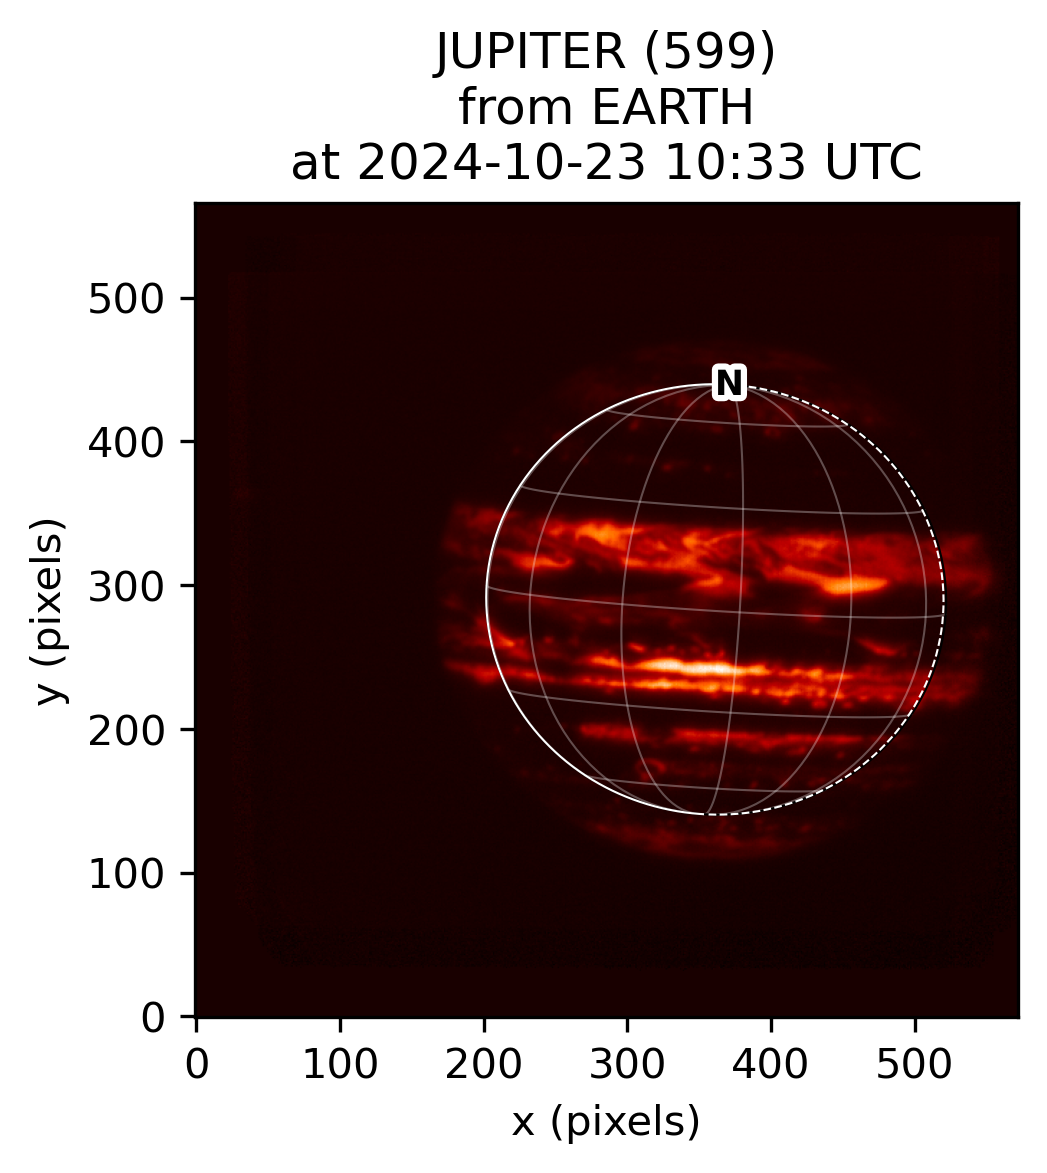

In [14]:
# for i in range(len(unique_first_img)):

%matplotlib inline

# night = unique_first_img
night = unique_second_img
test_index = 2 # 2024 [4] is what I used to compare the MainObs.png file to see the correct setup for the axes
path_to_prvt = '/Users/ahyder/Desktop/windfieldproject'
test_i = night[test_index].split('.cmap')[0]+'.fits.gz'
test_i_cmap = night[test_index]

hdul = fits.open(path_to_prvt + test_i)
hdr = hdul[0].header
print(hdr['DATE_OBS'], hdr['TIME_OBS'])
date_tag = hdr['DATE_OBS']
time_tag = hdr['TIME_OBS']
disc_x, disc_y = hdr['CX'], hdr['CY']
utc_str = date_tag + 'T' + time_tag
# This uses a JPG image, so we need to manually specify details (e.g. target)

observation = planetmapper.Observation(
    path_to_prvt + test_i,
    target='jupiter',
    utc=utc_str,
    observer='EARTH',
    show_progress=True, # show progress bars for slower functions
)
hdul.close()

# Set the disc parameters manually (from FITS header)
# r0 can be tuned to match your dataset
r0 = 160
observation.set_disc_params(x0=disc_x, y0=disc_y, r0=r0)

# Do a nice RGB plot of the data in the top left
rgb_img = np.moveaxis(observation.data, 0, 2)  # imshow needs wavelength index last
# rgb_img[~planet_mask] = np.nan

fig, axs = plt.subplots(
    nrows=1, ncols=1, figsize=(4, 4), dpi=300
)
axs.imshow(rgb_img, origin='lower', cmap='gist_heat')

observation.plot_wireframe_xy(axs, formatting={
                                      'grid': {'linestyle': '-', 'linewidth': 0.5, 'alpha': 0.3, 'color':'w'},
                                      'prime_meridian': {'linewidth': 1, 'color': 'r'},
                                      'terminator': {'linewidth': 0.5, 'color':'w'},
                                      'equator': {'linewidth': 2, 'color':'w'},
                                      'limb_illuminated': {'linewidth': 0.5, 'color':'w'},},
                                    indicate_equator=False,
                                )

# observation.plot_backplane_img('LON-CENTRIC', cmap='gray', alpha=0.5)

# observation.centre_disc()
fig.tight_layout()
plt.show()

In [15]:
'/Users/ahyder/Desktop/windfieldproject' + test_i_cmap

'/Users/ahyder/Desktop/windfieldproject/prvt/juno1/spex/2024oct23/images/5.10/jupiter/jc057087.cmap.gz'

In [16]:
test_i_cmap.split('.cmap')[0]+'.mu.gz'

'/prvt/juno1/spex/2024oct23/images/5.10/jupiter/jc057087.mu.gz'

360 180


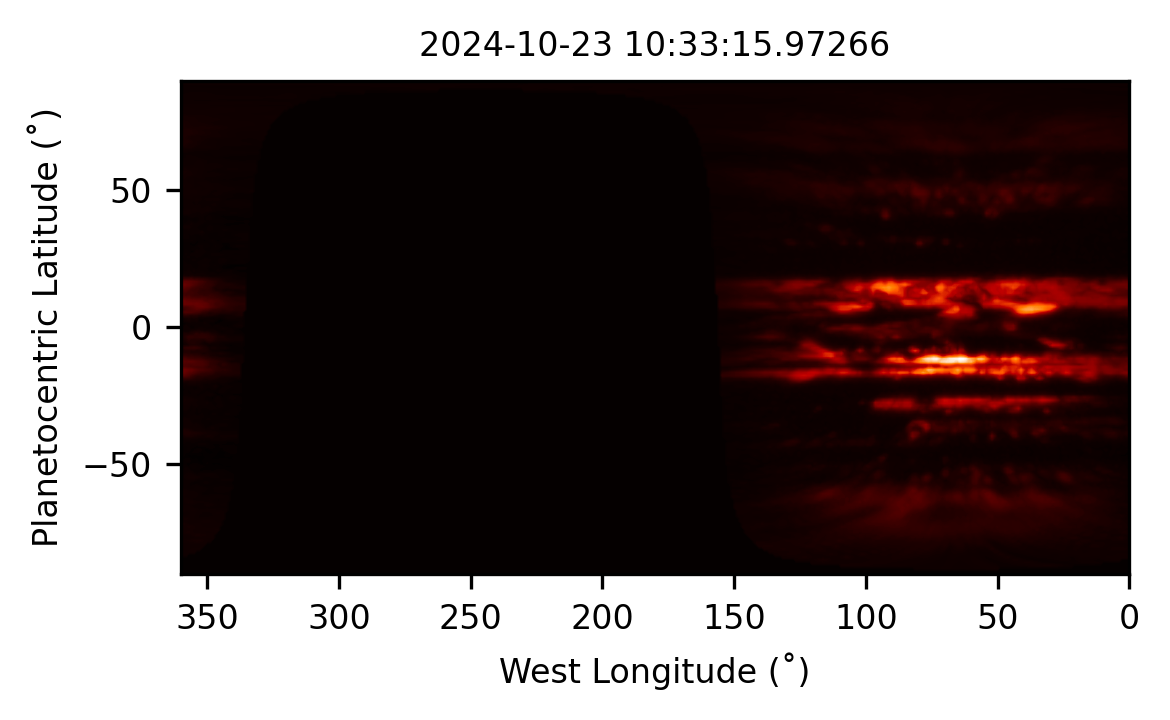

In [17]:
from mpl_toolkits import basemap
import cartopy.crs as ccrs

hdul_cm = fits.open('/Users/ahyder/Desktop/windfieldproject' + test_i_cmap)
hdul_mu = fits.open('/Users/ahyder/Desktop/windfieldproject' + test_i_cmap.split('.cmap')[0]+'.mu.gz')
hdul_mu_nan = hdul_mu[0].data
hdul_mu_nan[hdul_mu[0].data == 0] = np.nan

long_mesh, lat_mesh = np.meshgrid(np.linspace(0, 360, hdul_cm[0].header['NAXIS1']), np.linspace(-90, 90, hdul_cm[0].header['NAXIS2']))

print(hdul_cm[0].header['NAXIS1'], hdul_cm[0].header['NAXIS2'])
plt.figure(figsize=(4,2.5), dpi=300)
plt.contourf(np.linspace(0, 360, hdul_cm[0].header['NAXIS1'])[::-1], np.linspace(-90, 90, hdul_cm[0].header['NAXIS2']), 
             hdul_cm[0].data,
             256, cmap='gist_heat')
# plt.contourf(np.linspace(0, 360, hdul_cm[0].header['NAXIS1']), np.linspace(-90, 90, hdul_cm[0].header['NAXIS2']), 
#              hdul_cm[0].data / hdul_mu_nan, 
#              np.linspace(0, 1500, 256), cmap='gist_heat')
fs = '8'
plt.title(hdul_cm[0].header['DATE_OBS'] + ' ' + hdul_cm[0].header['TIME_OBS'], fontsize=fs)
plt.xlabel('West Longitude (˚)', fontsize=fs), plt.ylabel('Planetocentric Latitude (˚)', fontsize=fs)
plt.gca().tick_params(labelsize=8)
plt.gca().invert_xaxis()
plt.tight_layout()
hdul_cm.close()

plt.show()

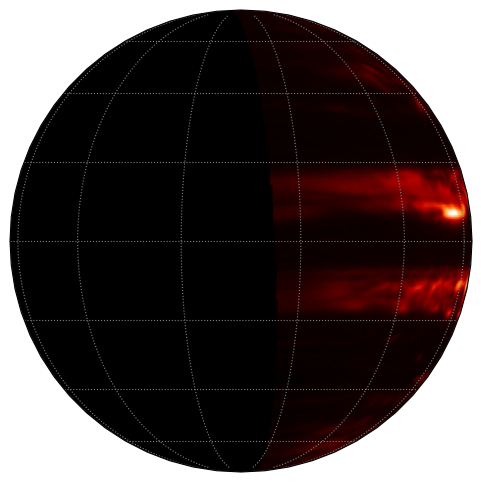

In [25]:
'''
Manual Cartopy mapping because planetMapper is fussy
'''

plt.figure(figsize=(6, 6))

ax = plt.axes(projection=ccrs.Orthographic(75, 0))
ax.gridlines(color='gray', linestyle='dotted')
ax.imshow(np.flipud(hdul_cm[0].data), origin="upper", interpolation='bicubic', extent=(0, 360, -90, 90), cmap='gist_heat',
          transform=ccrs.PlateCarree())  # Important

plt.show()

In [29]:
total_coadded_list = []
print('Date [Y/M/D] UTC [hh:mm:ss] \t Right Ascension [h:m:s] \t Declination [˚:\':\"] \t Airmass \t Filename \t Coadded Images')
for i in unique_full_array[::-1]:
    # print(i)
    i = i.strip()
    hdul = fits.open(path_to_prvt + i)
    hdr = hdul[0].header
    date = parser.parse(hdr['DATE_OBS']+ 'T' + hdr['TIME_OBS'])
    history_entries = hdr.get('HISTORY', [])
    # Ensure iterable if only one HISTORY exists
    if isinstance(history_entries, str):
        history_entries = [history_entries]
    # Count image entries
    n_coadd = sum('shifted by' in h for h in history_entries)
    total_coadded_list.append(n_coadd)
    # print(date, '\t', hdr['RA'], '\t', hdr['DEC'], '\t', hdr['AIRMASS'], '\t', i.split('jupiter/')[1].split('.cmap')[0])
    print(str(date.year)+'/'+str(date.month)+'/'+str(date.day), '\t', hdr['TIME_OBS'], '\t', hdr['RA'], '\t', hdr['DEC'], '\t', hdr['AIRMASS'], '\t', i.split('jupiter/')[1].split('.cmap')[0], '\t', n_coadd)
    hdul.close()

Date [Y/M/D] UTC [hh:mm:ss] 	 Right Ascension [h:m:s] 	 Declination [˚:':"] 	 Airmass 	 Filename 	 Coadded Images
2024/8/17 	 15:12:28.84375 	 05:02:52.94 	 22:05:19.31 	 1.2049343 	 jc148182 	 4
2024/8/17 	 16:02:25.58594 	 05:02:54.31 	 22:05:21.11 	 1.078786 	 jc329353 	 5
2024/10/23 	 10:33:15.97266 	 05:19:33.00 	 22:23:23.28 	 1.3307071 	 jc057087 	 9
2024/11/24 	 15:07:04.96875 	 05:06:41.54 	 22:10:21.35 	 1.7573915 	 jc790794 	 2
2024/10/23 	 15:04:59.125 	 05:19:30.67 	 22:23:21.12 	 1.0823919 	 jc833859 	 12
2024/11/24 	 15:04:35.8125 	 05:06:41.61 	 22:10:21.35 	 1.7299635 	 jc763767 	 3
2024/8/17 	 14:45:15.22656 	 05:02:52.24 	 22:05:18.23 	 1.3062363 	 jc042065 	 5
2024/11/23 	 09:30:52.83594 	 05:07:21.95 	 22:11:05.63 	 1.098637 	 jc046054 	 5
2024/10/22 	 10:15:05.88281 	 05:19:44.97 	 22:23:34.44 	 1.4519206 	 jc055090 	 7
2024/11/23 	 09:31:41.05469 	 05:07:21.93 	 22:11:05.63 	 1.0968246 	 jc056062 	 4
2024/8/16 	 19:50:05.20312 	 05:02:22.03 	 22:04:37.55 	 1.1622

In [37]:
total_coadded_list = np.array(total_coadded_list)
print(total_coadded_list, len(np.where(total_coadded_list==0)[0])/len(total_coadded_list)*100)
print()

[ 4  5  9  2 12  3  5  5  7  4  5  9  4  8 16 11  4  4  2  8  0  4  4  3
  3  5  2  0  8  0  0  2 15  4  7  3 10 10 13  5 10 14  2  6 14  0  6  2
  6  3  3 10  3  0  0 12 10  0 18 14 18 18 18  4 11 10 10 12  7 10 10 11
 11 18  7 14 10 18  6  4  4  3  9 11  4  8 11 15  5  6  7 11  4  2 13 11
 16  5 11  6  7 12 13  7  4  8  3  6  5  3 18 17  9  2 16  3  3  0 14  2
  2 14  3  2 15 15 16  9  9  8  4  7  9  9  9  6  6] 6.569343065693431



In [27]:
#2016
# may11/jcf0057500592, may12/jcf0000100008 , 20.356535916944445
# may11/jcf0057500592, may12/jcf0009900116 , 20.734795466666668
# may11/jcf0057500592, may12/jcf0003100048 , 20.51384277527778
# may11/jcf0072300740, may12/jcf0000100008 , 19.2100184475
# may11/jcf0072300740, may12/jcf0009900116 , 19.58827799722222
# may11/jcf0072300740, may12/jcf0017700194 , 20.66119737527778
# may11/jcf0072300740, may12/jcf0003100048 , 19.367325305833333
# may11/jcf0053300544, may12/jcf0000100008 , 20.489799805833336
# may11/jcf0053300544, may12/jcf0003100048 , 20.647106664166667
# nov1  jcf0022700356, nov2  jcf0000100014 , 20.062731119444447
# nov1  jcf0022700356, nov2  jcf0003700060 , 20.274637585833332

#2017
# jul10/jcf0011900121, jul11/jcf0031300328 , 19.061035833055556
# jul10/jcf0011900121, jul11/jcf0061300628 , 19.936545271944443
# jul10/jcf0011900121, jul11/jcf0078100784 , 20.461524249999997
# jul10/jcf0011900121, jul11/jcf0056700568 , 19.828009384166666
# jul10/jcf0011900121, jul11/jcf08230828   , 20.570104980555556
# jul10/jcf0011900121, jul11/jcf0082300841 , 20.570104980555556 # duplicate? --> Yes
# may19/jcf161195    , may20/jcf031065     , 19.731768119444443
# may19/jcf161195    , may20/jcf149181     , 20.15121961638889
# may19/jcf031065    , may20/jcf031065     , 20.321738280555554
# may19/jcf031065    , may20/jcf149181     , 20.7411897775
# may19/jcf343377    , may20/jcf149181     , 19.257887369166667

#2018
# jul20/jcf0129101339, jul21/jcf0017500209, 19.735724824722222
# jul20/jcf0129101339, jul21/jcf0000100018, 19.178036294166667
# jul20/jcf0129101339, jul21/jcf0004900083, 19.32877929722222
# jul20/jcf0137501379, jul21/jcf0017500209, 19.607294919166666
# jul20/jcf0137501379, jul21/jcf0000100018, 19.049606388611114
# jul20/jcf0137501379, jul21/jcf0004900083, 19.200349391666666

#2019
# jan16/jc12271254, jan17 jc383426, 20.529965277777777
# jan16/jc12271254, jan17 jc469502, 20.712801650277775
# jan16/jc12271254, jan17 jc181206, 19.663234591944445
# jan16/jc12271254, jan17 jc249282, 19.834455297500003
# jan16/jc925038  , jan17 jc015034, 20.113432074722223
# jan16/jc925038  , jan17 jc069094, 20.276461588611113
# jan16/jc008026  , jan17 jc953894, 28.8147602
# jan16/jc756782  , jan17 jc015034, 20.701194660833334
# jan16/jc825860  , jan17 jc015034, 20.520276694444444
# jan16/jc825860  , jan17 jc069094, 20.683306208333335
# jan16/jc8911014 , jan17 jc015034, 19.90050238888889
# jan16/jc8911014 , jan17 jc069094, 20.06353190277778
# jan16/jc11471172, jan17 jc383426, 20.730028210833336
# jan16/jc11471172, jan17 jc015034, 18.877396919166667
# jan16/jc11471172, jan17 jc181206, 19.863297525
# jan16/jc11471172, jan17 jc249282, 20.034518230555555
# jan16/jc11471172, jan17 jc069094, 19.040426433055558

#2020
# dec23/jc647666, dec24/jc061096, 20.271231283333336
# dec23/jc647666, dec24/jc155168, 20.76790621083333
# dec23/jc647666, dec24/jc001020, 20.11556722222222
# dec23/jc721738, dec24/jc061096, 19.9202072475
# dec23/jc721738, dec24/jc155168, 20.416882175
# dec23/jc721738, dec24/jc001020, 19.764543186388888
# jul4 /jc039069, jul5 /jc613648, 29.305873480555558
# jul4 /jc683718, jul5 /jc001010, 20.547506511111113
# jul4 /jc683718, jul5 /jc041076, 20.68088216083333
# nov10/jc633668, nov11/jc041076, 19.89143978611111
# nov7 /jc585602, nov8 /jc183206, 20.357178819444446
# nov7 /jc689700, nov8 /jc183206, 19.84476671111111

#2021
# jul21/jc551572  , jul22/jc031066  , 20.534627822500003
# jul21/jc909922  , jul22/jc193228  , 20.066291230555557
# jul21/jc909922  , jul22/jc031066  , 19.192740886111114
# jul21/jc10251060, jul22/jc549584  , 20.813680555555557
# jul21/jc10251060, jul22/jc193228  , 19.327508677777775
# jul21/jc10251060, jul22/jc433468  , 20.414277341388885
# jul21/jc727756  , jul22/jc193228  , 20.726264105555558
# jul21/jc727756  , jul22/jc031066  , 19.852713761111108
# jul21/jc031064  , jul22/jc10491082, 29.307483716666667
# jul21/jc607618  , jul22/jc031066  , 20.392644316666665
# jun7 /jc585618  , jun8 /jc065092  , 19.216878255555553
# jun7 /jc031062  , jun8 /jc722751  , 29.506205510833333
# oct17/jc867902  , oct18/jc081116  , 19.983520777777777
# oct17/jc045070  , oct18/jc579614  , 29.225857205555556
# sep4//jc635662  , sep5 /jc231260  , 20.193433160833333
# sep4 /jc483512  , sep5 /jc033055  , 20.099975583055553

#2022
# apr8 /jc049050, apr9 /jc10291032 , 29.639534166388888
# apr8 /jc371372, apr9 /jc043076   , 20.653605382222224
# apr8 /jc601602, apr9 /jc043076   , 19.449310561388888
# apr8 /jc601602, apr9 /jc233256   , 20.52702866111111
# apr8 /jc491506, apr9 /jc043076   , 19.740253905833335
# apr8 /jc491506, apr9 /jc233256   , 20.817972005555553
# aug17/jc549580, aug18/jc265296   , 20.538168402777778
# aug17/jc549580, aug18/jc037056   , 19.194333766666666
# jan14/jc713732, jan15/jc090091   , 20.026690725555554
# jul8 /jc634661, jul9 /jc031066   , 18.929657119444443
# jul8 /jc031064, jul9 /jc10191086 , 29.64124891638889
# jul8 /jc031064, jul9 /jc895930   , 29.136117621944443
# may21/jc371397, may22/jc301326   , 20.433970269166668

#2023 # total: 17
# dec28/jc507541, dec29/jc173208   , 19.44807183361111
# jun23/jc089090, jun24/jc773774   , 29.033634533888886
# jun23/jc121154, jun24/jc773774   , 28.892776648055555
# may16/jc786797, may17/jc011012   , 20.077836163055558
# may16/jc786797, may17/jc089118   , 20.222992619444444
# may16/jc786797, may17/jc347414   , 20.76377170027778
# may16/jc031054, may17/jc19792030 , 29.88057942777778
# may16/jc031054, may17/jc17371764 , 29.48338758611111
# may16/jc031054, may17/jc19191920 , 29.75600521138889
# may16/jc031054, may17/jc16591674 , 29.101816405555553
# may16/jc031054, may17/jc18111876 , 29.63198133611111
# may16/jc786793, may17/jc011012   , 20.082614810000003
# may16/jc786793, may17/jc089118   , 20.22777126638889
# may16/jc786793, may17/jc347414   , 20.768550347222224
# nov22/jc759785, nov23/jc165200   , 19.2021983525
# nov22/jc575609, nov23/jc165200   , 20.004598524722223
# oct14/jc631664, oct15/jc119154   , 19.80983832472222

#2024
# aug16/jc183201, aug17/jc042065 , 18.919450955277778
# aug16/jc183201, aug17/jc329353 , 20.205661894444443
# aug16/jc183201, aug17/jc148182 , 19.373233508333332
# aug16/jc523554, aug17/jc042065 , 20.52804470555556
# aug16/jc815843, aug17/jc042065 , 18.91849826388889
# aug16/jc815843, aug17/jc329353 , 20.204709203055558
# aug16/jc815843, aug17/jc148182 , 19.372280816944443
# aug16/jc649676, aug17/jc042065 , 20.091280380277777
# aug16/jc649676, aug17/jc148182 , 20.54506293333333
# oct22/jc505516, oct23/jc057087 , 20.521971571944448
# oct22/jc055090, oct23/jc833859 , 28.83145616388889
# oct22/jc451486, oct23/jc057087 , 20.66405490527778

# nov23/jc046054, nov24/jc763767 , 29.561937933333333
# nov23/jc046054, nov24/jc790794 , 29.603370225
# nov23/jc039045, nov24/jc763767 , 29.5736230475
# nov23/jc039045, nov24/jc790794 , 29.615055339166666
# nov23/jc056062, nov24/jc763767 , 29.54854383611111
# nov23/jc056062, nov24/jc790794 , 29.589976127777778
# nov23/jc031037, nov24/jc763767 , 29.585512152777778
# nov23/jc031037, nov24/jc790794 , 29.626944444444444

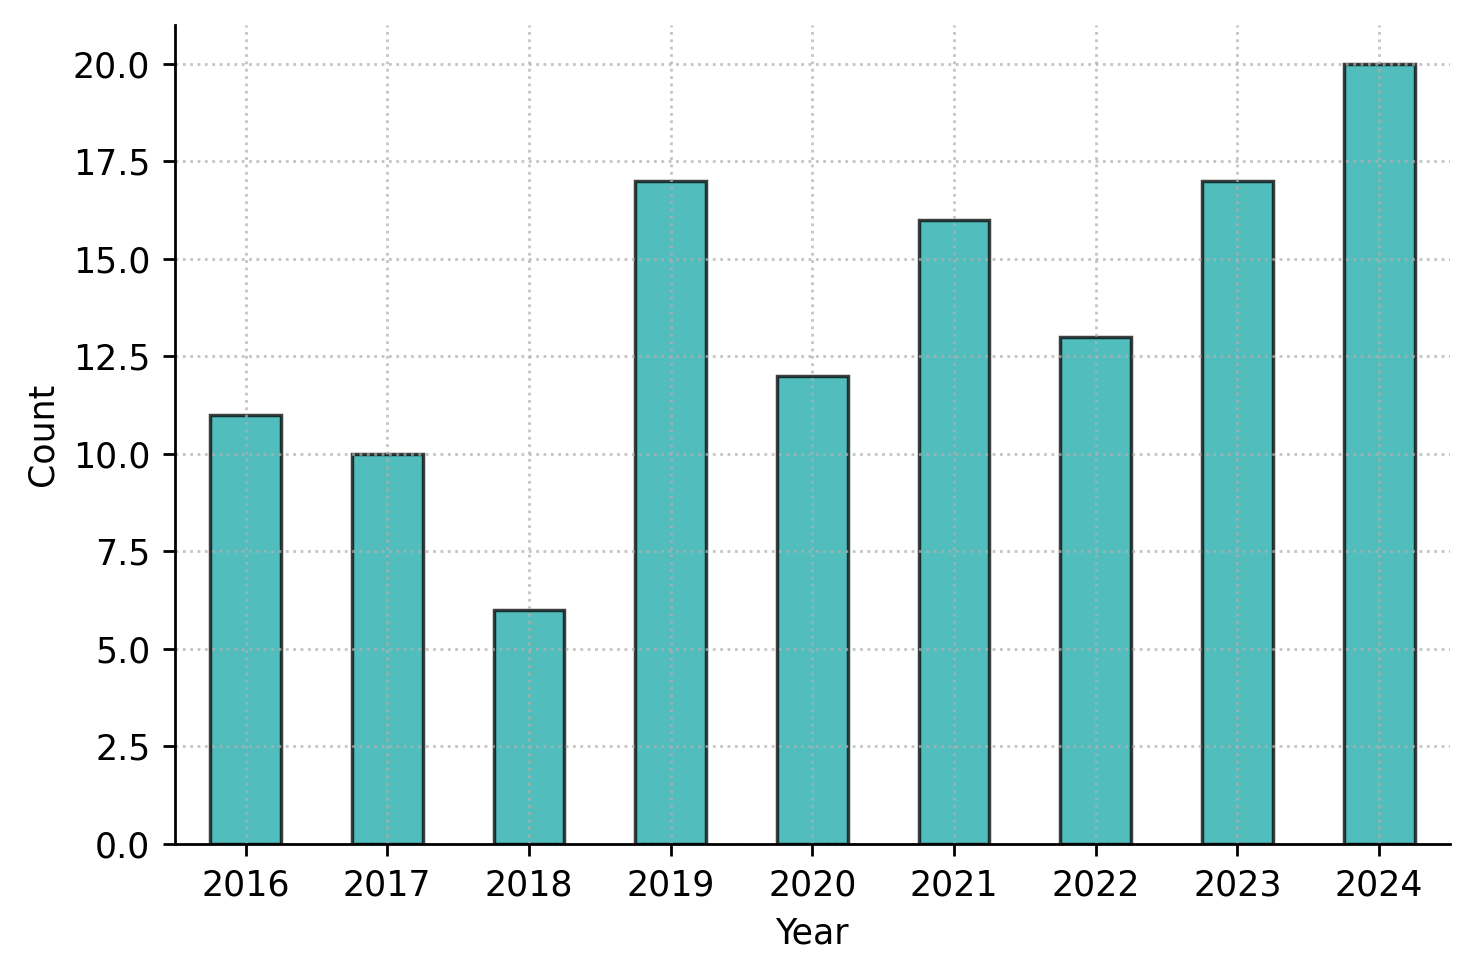

In [28]:
lines = [
" /prvt/cirs12/spex/2016may11/images/5.10/jupiter/jcf0057500592.cmap.gz , /prvt/cirs12/spex/2016may12/images/5.10/jupiter/jcf0000100008.cmap.gz , 20.356535916944445 " ,
" /prvt/cirs12/spex/2016may11/images/5.10/jupiter/jcf0057500592.cmap.gz , /prvt/cirs12/spex/2016may12/images/5.10/jupiter/jcf0009900116.cmap.gz , 20.734795466666668 " ,
" /prvt/cirs12/spex/2016may11/images/5.10/jupiter/jcf0057500592.cmap.gz , /prvt/cirs12/spex/2016may12/images/5.10/jupiter/jcf0003100048.cmap.gz , 20.51384277527778 " ,
" /prvt/cirs12/spex/2016may11/images/5.10/jupiter/jcf0072300740.cmap.gz , /prvt/cirs12/spex/2016may12/images/5.10/jupiter/jcf0000100008.cmap.gz , 19.2100184475 " ,
" /prvt/cirs12/spex/2016may11/images/5.10/jupiter/jcf0072300740.cmap.gz , /prvt/cirs12/spex/2016may12/images/5.10/jupiter/jcf0009900116.cmap.gz , 19.58827799722222 " ,
" /prvt/cirs12/spex/2016may11/images/5.10/jupiter/jcf0072300740.cmap.gz , /prvt/cirs12/spex/2016may12/images/5.10/jupiter/jcf0017700194.cmap.gz , 20.66119737527778 " ,
" /prvt/cirs12/spex/2016may11/images/5.10/jupiter/jcf0072300740.cmap.gz , /prvt/cirs12/spex/2016may12/images/5.10/jupiter/jcf0003100048.cmap.gz , 19.367325305833333 " ,
" /prvt/cirs12/spex/2016may11/images/5.10/jupiter/jcf0053300544.cmap.gz , /prvt/cirs12/spex/2016may12/images/5.10/jupiter/jcf0000100008.cmap.gz , 20.489799805833336 " ,
" /prvt/cirs12/spex/2016may11/images/5.10/jupiter/jcf0053300544.cmap.gz , /prvt/cirs12/spex/2016may12/images/5.10/jupiter/jcf0003100048.cmap.gz , 20.647106664166667 " ,
" /prvt/cirs12/spex/2016nov1/5.10/jupiter/jcf0022700356.cmap.gz , /prvt/cirs12/spex/2016nov2/5.10/jupiter/jcf0000100014.cmap.gz , 20.062731119444447 " ,
" /prvt/cirs12/spex/2016nov1/5.10/jupiter/jcf0022700356.cmap.gz , /prvt/cirs12/spex/2016nov2/5.10/jupiter/jcf0003700060.cmap.gz , 20.274637585833332 " ,
" /prvt/cirs12/spex/2017jul10/5.10/jupiter/jcf0011900121.cmap.gz , /prvt/cirs12/spex/2017jul11/5.10/jupiter/jcf0031300328.cmap.gz , 19.061035833055556 " ,
" /prvt/cirs12/spex/2017jul10/5.10/jupiter/jcf0011900121.cmap.gz , /prvt/cirs12/spex/2017jul11/5.10/jupiter/jcf0061300628.cmap.gz , 19.936545271944443 " ,
" /prvt/cirs12/spex/2017jul10/5.10/jupiter/jcf0011900121.cmap.gz , /prvt/cirs12/spex/2017jul11/5.10/jupiter/jcf0078100784.cmap.gz , 20.461524249999997 " ,
" /prvt/cirs12/spex/2017jul10/5.10/jupiter/jcf0011900121.cmap.gz , /prvt/cirs12/spex/2017jul11/5.10/jupiter/jcf0056700568.cmap.gz , 19.828009384166666 " ,
" /prvt/cirs12/spex/2017jul10/5.10/jupiter/jcf0011900121.cmap.gz , /prvt/cirs12/spex/2017jul11/5.10/jupiter/jcf08230828.cmap.gz , 20.570104980555556 " ,
" /prvt/cirs12/spex/2017may19/5.10/jupiter/jcf161195.cmap.gz , /prvt/cirs12/spex/2017may20/5.10/jupiter/jcf031065.cmap.gz , 19.731768119444443 " ,
" /prvt/cirs12/spex/2017may19/5.10/jupiter/jcf161195.cmap.gz , /prvt/cirs12/spex/2017may20/5.10/jupiter/jcf149181.cmap.gz , 20.15121961638889 " ,
" /prvt/cirs12/spex/2017may19/5.10/jupiter/jcf031065.cmap.gz , /prvt/cirs12/spex/2017may20/5.10/jupiter/jcf031065.cmap.gz , 20.321738280555554 " ,
" /prvt/cirs12/spex/2017may19/5.10/jupiter/jcf031065.cmap.gz , /prvt/cirs12/spex/2017may20/5.10/jupiter/jcf149181.cmap.gz , 20.7411897775 " ,
" /prvt/cirs12/spex/2017may19/5.10/jupiter/jcf343377.cmap.gz , /prvt/cirs12/spex/2017may20/5.10/jupiter/jcf149181.cmap.gz , 19.257887369166667 " ,
" /prvt/cirs12/spex/2018jul20/5.10/jupiter/jcf0129101339.cmap.gz , /prvt/cirs12/spex/2018jul21/5.10/jupiter/jcf0017500209.cmap.gz , 19.735724824722222 " ,
" /prvt/cirs12/spex/2018jul20/5.10/jupiter/jcf0129101339.cmap.gz , /prvt/cirs12/spex/2018jul21/5.10/jupiter/jcf0000100018.cmap.gz , 19.178036294166667 " ,
" /prvt/cirs12/spex/2018jul20/5.10/jupiter/jcf0129101339.cmap.gz , /prvt/cirs12/spex/2018jul21/5.10/jupiter/jcf0004900083.cmap.gz , 19.32877929722222 " ,
" /prvt/cirs12/spex/2018jul20/5.10/jupiter/jcf0137501379.cmap.gz , /prvt/cirs12/spex/2018jul21/5.10/jupiter/jcf0017500209.cmap.gz , 19.607294919166666 " ,
" /prvt/cirs12/spex/2018jul20/5.10/jupiter/jcf0137501379.cmap.gz , /prvt/cirs12/spex/2018jul21/5.10/jupiter/jcf0000100018.cmap.gz , 19.049606388611114 " ,
" /prvt/cirs12/spex/2018jul20/5.10/jupiter/jcf0137501379.cmap.gz , /prvt/cirs12/spex/2018jul21/5.10/jupiter/jcf0004900083.cmap.gz , 19.200349391666666 " ,
" /prvt/juno1/spex/2019jan16/images/5.10/jupiter/jc12271254.cmap.gz , /prvt/juno1/spex/2019jan17/images/5.10/jupiter/jc383426.cmap.gz , 20.529965277777777 " ,
" /prvt/juno1/spex/2019jan16/images/5.10/jupiter/jc12271254.cmap.gz , /prvt/juno1/spex/2019jan17/images/5.10/jupiter/jc469502.cmap.gz , 20.712801650277775 " ,
" /prvt/juno1/spex/2019jan16/images/5.10/jupiter/jc12271254.cmap.gz , /prvt/juno1/spex/2019jan17/images/5.10/jupiter/jc181206.cmap.gz , 19.663234591944445 " ,
" /prvt/juno1/spex/2019jan16/images/5.10/jupiter/jc12271254.cmap.gz , /prvt/juno1/spex/2019jan17/images/5.10/jupiter/jc249282.cmap.gz , 19.834455297500003 " ,
" /prvt/juno1/spex/2019jan16/images/5.10/jupiter/jc925038.cmap.gz , /prvt/juno1/spex/2019jan17/images/5.10/jupiter/jc015034.cmap.gz , 20.113432074722223 " ,
" /prvt/juno1/spex/2019jan16/images/5.10/jupiter/jc925038.cmap.gz , /prvt/juno1/spex/2019jan17/images/5.10/jupiter/jc069094.cmap.gz , 20.276461588611113 " ,
" /prvt/juno1/spex/2019jan16/images/5.10/jupiter/jc008026.cmap.gz , /prvt/juno1/spex/2019jan17/images/5.10/jupiter/jc953894.cmap.gz , 28.8147602 " ,
" /prvt/juno1/spex/2019jan16/images/5.10/jupiter/jc756782.cmap.gz , /prvt/juno1/spex/2019jan17/images/5.10/jupiter/jc015034.cmap.gz , 20.701194660833334 " ,
" /prvt/juno1/spex/2019jan16/images/5.10/jupiter/jc825860.cmap.gz , /prvt/juno1/spex/2019jan17/images/5.10/jupiter/jc015034.cmap.gz , 20.520276694444444 " ,
" /prvt/juno1/spex/2019jan16/images/5.10/jupiter/jc825860.cmap.gz , /prvt/juno1/spex/2019jan17/images/5.10/jupiter/jc069094.cmap.gz , 20.683306208333335 " ,
" /prvt/juno1/spex/2019jan16/images/5.10/jupiter/jc8911014.cmap.gz , /prvt/juno1/spex/2019jan17/images/5.10/jupiter/jc015034.cmap.gz , 19.90050238888889 " ,
" /prvt/juno1/spex/2019jan16/images/5.10/jupiter/jc8911014.cmap.gz , /prvt/juno1/spex/2019jan17/images/5.10/jupiter/jc069094.cmap.gz , 20.06353190277778 " ,
" /prvt/juno1/spex/2019jan16/images/5.10/jupiter/jc11471172.cmap.gz , /prvt/juno1/spex/2019jan17/images/5.10/jupiter/jc383426.cmap.gz , 20.730028210833336 " ,
" /prvt/juno1/spex/2019jan16/images/5.10/jupiter/jc11471172.cmap.gz , /prvt/juno1/spex/2019jan17/images/5.10/jupiter/jc015034.cmap.gz , 18.877396919166667 " ,
" /prvt/juno1/spex/2019jan16/images/5.10/jupiter/jc11471172.cmap.gz , /prvt/juno1/spex/2019jan17/images/5.10/jupiter/jc181206.cmap.gz , 19.863297525 " ,
" /prvt/juno1/spex/2019jan16/images/5.10/jupiter/jc11471172.cmap.gz , /prvt/juno1/spex/2019jan17/images/5.10/jupiter/jc249282.cmap.gz , 20.034518230555555 " ,
" /prvt/juno1/spex/2019jan16/images/5.10/jupiter/jc11471172.cmap.gz , /prvt/juno1/spex/2019jan17/images/5.10/jupiter/jc069094.cmap.gz , 19.040426433055558 " ,
" /prvt/juno1/spex/2020dec23/images/5.10/jupiter/jc647666.cmap.gz , /prvt/juno1/spex/2020dec24/images/5.10/jupiter/jc061096.cmap.gz , 20.271231283333336 " ,
" /prvt/juno1/spex/2020dec23/images/5.10/jupiter/jc647666.cmap.gz , /prvt/juno1/spex/2020dec24/images/5.10/jupiter/jc155168.cmap.gz , 20.76790621083333 " ,
" /prvt/juno1/spex/2020dec23/images/5.10/jupiter/jc647666.cmap.gz , /prvt/juno1/spex/2020dec24/images/5.10/jupiter/jc001020.cmap.gz , 20.11556722222222 " ,
" /prvt/juno1/spex/2020dec23/images/5.10/jupiter/jc721738.cmap.gz , /prvt/juno1/spex/2020dec24/images/5.10/jupiter/jc061096.cmap.gz , 19.9202072475 " ,
" /prvt/juno1/spex/2020dec23/images/5.10/jupiter/jc721738.cmap.gz , /prvt/juno1/spex/2020dec24/images/5.10/jupiter/jc155168.cmap.gz , 20.416882175 " ,
" /prvt/juno1/spex/2020dec23/images/5.10/jupiter/jc721738.cmap.gz , /prvt/juno1/spex/2020dec24/images/5.10/jupiter/jc001020.cmap.gz , 19.764543186388888 " ,
" /prvt/juno1/spex/2020jul4/images/5.10/jupiter/jc039069.cmap.gz , /prvt/juno1/spex/2020jul5/images/5.10/jupiter/jc613648.cmap.gz , 29.305873480555558 " ,
" /prvt/juno1/spex/2020jul4/images/5.10/jupiter/jc683718.cmap.gz , /prvt/juno1/spex/2020jul5/images/5.10/jupiter/jc001010.cmap.gz , 20.547506511111113 " ,
" /prvt/juno1/spex/2020jul4/images/5.10/jupiter/jc683718.cmap.gz , /prvt/juno1/spex/2020jul5/images/5.10/jupiter/jc041076.cmap.gz , 20.68088216083333 " ,
" /prvt/juno1/spex/2020nov10/images/5.10/jupiter/jc633668.cmap.gz , /prvt/juno1/spex/2020nov11/images/5.10/jupiter/jc041076.cmap.gz , 19.89143978611111 " ,
" /prvt/juno1/spex/2020nov7/images/5.10/jupiter/jc585602.cmap.gz , /prvt/juno1/spex/2020nov8/images/5.10/jupiter/jc183206.cmap.gz , 20.357178819444446 " ,
" /prvt/juno1/spex/2020nov7/images/5.10/jupiter/jc689700.cmap.gz , /prvt/juno1/spex/2020nov8/images/5.10/jupiter/jc183206.cmap.gz , 19.84476671111111 " ,
" /prvt/juno1/spex/2021jul21/images/5.10/jupiter/jc551572.cmap.gz , /prvt/juno1/spex/2021jul22/images/5.10/jupiter/jc031066.cmap.gz , 20.534627822500003 " ,
" /prvt/juno1/spex/2021jul21/images/5.10/jupiter/jc909922.cmap.gz , /prvt/juno1/spex/2021jul22/images/5.10/jupiter/jc193228.cmap.gz , 20.066291230555557 " ,
" /prvt/juno1/spex/2021jul21/images/5.10/jupiter/jc909922.cmap.gz , /prvt/juno1/spex/2021jul22/images/5.10/jupiter/jc031066.cmap.gz , 19.192740886111114 " ,
" /prvt/juno1/spex/2021jul21/images/5.10/jupiter/jc10251060.cmap.gz , /prvt/juno1/spex/2021jul22/images/5.10/jupiter/jc549584.cmap.gz , 20.813680555555557 " ,
" /prvt/juno1/spex/2021jul21/images/5.10/jupiter/jc10251060.cmap.gz , /prvt/juno1/spex/2021jul22/images/5.10/jupiter/jc193228.cmap.gz , 19.327508677777775 " ,
" /prvt/juno1/spex/2021jul21/images/5.10/jupiter/jc10251060.cmap.gz , /prvt/juno1/spex/2021jul22/images/5.10/jupiter/jc433468.cmap.gz , 20.414277341388885 " ,
" /prvt/juno1/spex/2021jul21/images/5.10/jupiter/jc727756.cmap.gz , /prvt/juno1/spex/2021jul22/images/5.10/jupiter/jc193228.cmap.gz , 20.726264105555558 " ,
" /prvt/juno1/spex/2021jul21/images/5.10/jupiter/jc727756.cmap.gz , /prvt/juno1/spex/2021jul22/images/5.10/jupiter/jc031066.cmap.gz , 19.852713761111108 " ,
" /prvt/juno1/spex/2021jul21/images/5.10/jupiter/jc031064.cmap.gz , /prvt/juno1/spex/2021jul22/images/5.10/jupiter/jc10491082.cmap.gz , 29.307483716666667 " ,
" /prvt/juno1/spex/2021jul21/images/5.10/jupiter/jc607618.cmap.gz , /prvt/juno1/spex/2021jul22/images/5.10/jupiter/jc031066.cmap.gz , 20.392644316666665 " ,
" /prvt/juno1/spex/2021jun7/images/5.10/jupiter/jc585618.cmap.gz , /prvt/juno1/spex/2021jun8/images/5.10/jupiter/jc065092.cmap.gz , 19.216878255555553 " ,
" /prvt/juno1/spex/2021jun7/images/5.10/jupiter/jc031062.cmap.gz , /prvt/juno1/spex/2021jun8/images/5.10/jupiter/jc722751.cmap.gz , 29.506205510833333 " ,
" /prvt/juno1/spex/2021oct17/images/5.10/jupiter/jc867902.cmap.gz , /prvt/juno1/spex/2021oct18/images/5.10/jupiter/jc081116.cmap.gz , 19.983520777777777 " ,
" /prvt/juno1/spex/2021oct17/images/5.10/jupiter/jc045070.cmap.gz , /prvt/juno1/spex/2021oct18/images/5.10/jupiter/jc579614.cmap.gz , 29.225857205555556 " ,
" /prvt/juno1/spex/2021sep4/images/5.10/jupiter/jc635662.cmap.gz , /prvt/juno1/spex/2021sep5/images/5.10/jupiter/jc231260.cmap.gz , 20.193433160833333 " ,
" /prvt/juno1/spex/2021sep4/images/5.10/jupiter/jc483512.cmap.gz , /prvt/juno1/spex/2021sep5/images/5.10/jupiter/jc033055.cmap.gz , 20.099975583055553 " ,
" /prvt/juno1/spex/2022apr8/images/5.10/jupiter/jc049050.cmap.gz , /prvt/juno1/spex/2022apr9/images/5.10/jupiter/jc10291032.cmap.gz , 29.639534166388888 " ,
" /prvt/juno1/spex/2022apr8/images/5.10/jupiter/jc371372.cmap.gz , /prvt/juno1/spex/2022apr9/images/5.10/jupiter/jc043076.cmap.gz , 20.653605382222224 " ,
" /prvt/juno1/spex/2022apr8/images/5.10/jupiter/jc601602.cmap.gz , /prvt/juno1/spex/2022apr9/images/5.10/jupiter/jc043076.cmap.gz , 19.449310561388888 " ,
" /prvt/juno1/spex/2022apr8/images/5.10/jupiter/jc601602.cmap.gz , /prvt/juno1/spex/2022apr9/images/5.10/jupiter/jc233256.cmap.gz , 20.52702866111111 " ,
" /prvt/juno1/spex/2022apr8/images/5.10/jupiter/jc491506.cmap.gz , /prvt/juno1/spex/2022apr9/images/5.10/jupiter/jc043076.cmap.gz , 19.740253905833335 " ,
" /prvt/juno1/spex/2022apr8/images/5.10/jupiter/jc491506.cmap.gz , /prvt/juno1/spex/2022apr9/images/5.10/jupiter/jc233256.cmap.gz , 20.817972005555553 " ,
" /prvt/juno1/spex/2022aug17/images/5.10/jupiter/jc549580.cmap.gz , /prvt/juno1/spex/2022aug18/images/5.10/jupiter/jc265296.cmap.gz , 20.538168402777778 " ,
" /prvt/juno1/spex/2022aug17/images/5.10/jupiter/jc549580.cmap.gz , /prvt/juno1/spex/2022aug18/images/5.10/jupiter/jc037056.cmap.gz , 19.194333766666666 " ,
" /prvt/juno1/spex/2022jan14/images/5.10/jupiter/jc713732.cmap.gz , /prvt/juno1/spex/2022jan15/images/5.10/jupiter/jc090091.cmap.gz , 20.026690725555554 " ,
" /prvt/juno1/spex/2022jul8/images/5.10/jupiter/jc634661.cmap.gz , /prvt/juno1/spex/2022jul9/images/5.10/jupiter/jc031066.cmap.gz , 18.929657119444443 " ,
" /prvt/juno1/spex/2022jul8/images/5.10/jupiter/jc031064.cmap.gz , /prvt/juno1/spex/2022jul9/images/5.10/jupiter/jc10191086.cmap.gz , 29.64124891638889 " ,
" /prvt/juno1/spex/2022jul8/images/5.10/jupiter/jc031064.cmap.gz , /prvt/juno1/spex/2022jul9/images/5.10/jupiter/jc895930.cmap.gz , 29.136117621944443 " ,
" /prvt/juno1/spex/2022may21/images/5.10/jupiter/jc371397.cmap.gz , /prvt/juno1/spex/2022may22/images/5.10/jupiter/jc301326.cmap.gz , 20.433970269166668 " ,
" /prvt/juno1/spex/2023dec28/images/5.10/jupiter/jc507541.cmap.gz , /prvt/juno1/spex/2023dec29/images/5.10/jupiter/jc173208.cmap.gz , 19.44807183361111 " ,
" /prvt/juno1/spex/2023jun23/images/5.10/jupiter/jc089090.cmap.gz , /prvt/juno1/spex/2023jun24/images/5.10/jupiter/jc773774.cmap.gz , 29.033634533888886 " ,
" /prvt/juno1/spex/2023jun23/images/5.10/jupiter/jc121154.cmap.gz , /prvt/juno1/spex/2023jun24/images/5.10/jupiter/jc773774.cmap.gz , 28.892776648055555 " ,
" /prvt/juno1/spex/2023may16/images/5.10/jupiter/jc786797.cmap.gz , /prvt/juno1/spex/2023may17/images/5.10/jupiter/jc011012.cmap.gz , 20.077836163055558 " ,
" /prvt/juno1/spex/2023may16/images/5.10/jupiter/jc786797.cmap.gz , /prvt/juno1/spex/2023may17/images/5.10/jupiter/jc089118.cmap.gz , 20.222992619444444 " ,
" /prvt/juno1/spex/2023may16/images/5.10/jupiter/jc786797.cmap.gz , /prvt/juno1/spex/2023may17/images/5.10/jupiter/jc347414.cmap.gz , 20.76377170027778 " ,
" /prvt/juno1/spex/2023may16/images/5.10/jupiter/jc031054.cmap.gz , /prvt/juno1/spex/2023may17/images/5.10/jupiter/jc19792030.cmap.gz , 29.88057942777778 " ,
" /prvt/juno1/spex/2023may16/images/5.10/jupiter/jc031054.cmap.gz , /prvt/juno1/spex/2023may17/images/5.10/jupiter/jc17371764.cmap.gz , 29.48338758611111 " ,
" /prvt/juno1/spex/2023may16/images/5.10/jupiter/jc031054.cmap.gz , /prvt/juno1/spex/2023may17/images/5.10/jupiter/jc19191920.cmap.gz , 29.75600521138889 " ,
" /prvt/juno1/spex/2023may16/images/5.10/jupiter/jc031054.cmap.gz , /prvt/juno1/spex/2023may17/images/5.10/jupiter/jc16591674.cmap.gz , 29.101816405555553 " ,
" /prvt/juno1/spex/2023may16/images/5.10/jupiter/jc031054.cmap.gz , /prvt/juno1/spex/2023may17/images/5.10/jupiter/jc18111876.cmap.gz , 29.63198133611111 " ,
" /prvt/juno1/spex/2023may16/images/5.10/jupiter/jc786793.cmap.gz , /prvt/juno1/spex/2023may17/images/5.10/jupiter/jc011012.cmap.gz , 20.082614810000003 " ,
" /prvt/juno1/spex/2023may16/images/5.10/jupiter/jc786793.cmap.gz , /prvt/juno1/spex/2023may17/images/5.10/jupiter/jc089118.cmap.gz , 20.22777126638889 " ,
" /prvt/juno1/spex/2023may16/images/5.10/jupiter/jc786793.cmap.gz , /prvt/juno1/spex/2023may17/images/5.10/jupiter/jc347414.cmap.gz , 20.768550347222224 " ,
" /prvt/juno1/spex/2023nov22/images/5.10/jupiter/jc759785.cmap.gz , /prvt/juno1/spex/2023nov23/images/5.10/jupiter/jc165200.cmap.gz , 19.2021983525 " ,
" /prvt/juno1/spex/2023nov22/images/5.10/jupiter/jc575609.cmap.gz , /prvt/juno1/spex/2023nov23/images/5.10/jupiter/jc165200.cmap.gz , 20.004598524722223 " ,
" /prvt/juno1/spex/2023oct14/images/5.10/jupiter/jc631664.cmap.gz , /prvt/juno1/spex/2023oct15/images/5.10/jupiter/jc119154.cmap.gz , 19.80983832472222 " ,
" /prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc183201.cmap.gz , /prvt/juno1/spex/2024aug17/images/5.10/jupiter/jc042065.cmap.gz , 18.919450955277778 " ,
" /prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc183201.cmap.gz , /prvt/juno1/spex/2024aug17/images/5.10/jupiter/jc329353.cmap.gz , 20.205661894444443 " ,
" /prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc183201.cmap.gz , /prvt/juno1/spex/2024aug17/images/5.10/jupiter/jc148182.cmap.gz , 19.373233508333332 " ,
" /prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc523554.cmap.gz , /prvt/juno1/spex/2024aug17/images/5.10/jupiter/jc042065.cmap.gz , 20.52804470555556 " ,
" /prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc815843.cmap.gz , /prvt/juno1/spex/2024aug17/images/5.10/jupiter/jc042065.cmap.gz , 18.91849826388889 " ,
" /prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc815843.cmap.gz , /prvt/juno1/spex/2024aug17/images/5.10/jupiter/jc329353.cmap.gz , 20.204709203055558 " ,
" /prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc815843.cmap.gz , /prvt/juno1/spex/2024aug17/images/5.10/jupiter/jc148182.cmap.gz , 19.372280816944443 " ,
" /prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc649676.cmap.gz , /prvt/juno1/spex/2024aug17/images/5.10/jupiter/jc042065.cmap.gz , 20.091280380277777 " ,
" /prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc649676.cmap.gz , /prvt/juno1/spex/2024aug17/images/5.10/jupiter/jc148182.cmap.gz , 20.54506293333333 " ,
" /prvt/juno1/spex/2024oct22/images/5.10/jupiter/jc505516.cmap.gz , /prvt/juno1/spex/2024oct23/images/5.10/jupiter/jc057087.cmap.gz , 20.521971571944448 " ,
" /prvt/juno1/spex/2024oct22/images/5.10/jupiter/jc055090.cmap.gz , /prvt/juno1/spex/2024oct23/images/5.10/jupiter/jc833859.cmap.gz , 28.83145616388889 " ,
" /prvt/juno1/spex/2024oct22/images/5.10/jupiter/jc451486.cmap.gz , /prvt/juno1/spex/2024oct23/images/5.10/jupiter/jc057087.cmap.gz , 20.66405490527778 " ,
" /prvt/juno1/spex/2024nov23/images/5.10/jupiter/jc046054.cmap.gz , /prvt/juno1/spex/2024nov24/images/5.10/jupiter/jc763767.cmap.gz , 29.561937933333333 " ,
" /prvt/juno1/spex/2024nov23/images/5.10/jupiter/jc046054.cmap.gz , /prvt/juno1/spex/2024nov24/images/5.10/jupiter/jc790794.cmap.gz , 29.603370225 " ,
" /prvt/juno1/spex/2024nov23/images/5.10/jupiter/jc039045.cmap.gz , /prvt/juno1/spex/2024nov24/images/5.10/jupiter/jc763767.cmap.gz , 29.5736230475 " ,
" /prvt/juno1/spex/2024nov23/images/5.10/jupiter/jc039045.cmap.gz , /prvt/juno1/spex/2024nov24/images/5.10/jupiter/jc790794.cmap.gz , 29.615055339166666 " ,
" /prvt/juno1/spex/2024nov23/images/5.10/jupiter/jc056062.cmap.gz , /prvt/juno1/spex/2024nov24/images/5.10/jupiter/jc763767.cmap.gz , 29.54854383611111 " ,
" /prvt/juno1/spex/2024nov23/images/5.10/jupiter/jc056062.cmap.gz , /prvt/juno1/spex/2024nov24/images/5.10/jupiter/jc790794.cmap.gz , 29.589976127777778 " ,
" /prvt/juno1/spex/2024nov23/images/5.10/jupiter/jc031037.cmap.gz , /prvt/juno1/spex/2024nov24/images/5.10/jupiter/jc763767.cmap.gz , 29.585512152777778 " ,
" /prvt/juno1/spex/2024nov23/images/5.10/jupiter/jc031037.cmap.gz , /prvt/juno1/spex/2024nov24/images/5.10/jupiter/jc790794.cmap.gz , 29.626944444444444 " 
]

# Extract the first year appearing in each line using regex
years = [re.search(r'/(\d{4})', line).group(1) for line in lines]

# Create DataFrame
df = pd.DataFrame({'Year': years})

# Convert to numeric for sorting
df['Year'] = df['Year'].astype(int)

%matplotlib inline
# Create Seaborn count plot
plt.figure(figsize=(6,4), dpi=250)
sns.countplot(data=df, x='Year', width=0.5, color='c', edgecolor='k', alpha=0.75)

# plt.title('Number of Observation Pairs per Year')
plt.xlabel('Year')
plt.ylabel('Count')
sns.despine()
plt.tight_layout()
plt.grid(True, ls=':', alpha=0.75)
plt.show()